In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

In [74]:
df=pd.read_csv(r'Fifa.csv')
df

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
...,...,...,...,...,...,...,...,...,...
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481


---
## Task 1 — Exploratory Data Analysis (EDA)

In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  str    
 1   Country            19667 non-null  str    
 2   Position           19667 non-null  str    
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  str    
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 2.0 MB


In [76]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

### there are no missing values

In [77]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


Skewness: 7.983
Mean: 2.51
Median: 0.68


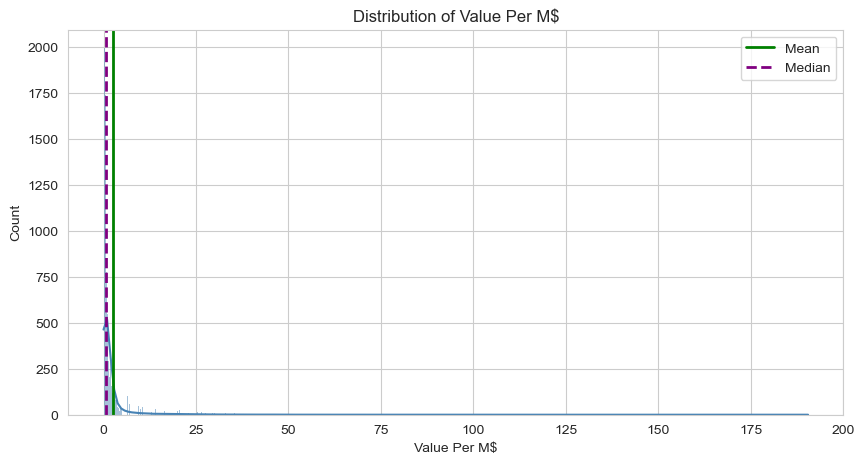

In [78]:

target = 'Value Per M$'

#compute skewness
skewness = df['Value Per M$'].skew()  
print(f"Skewness: {skewness:.3f}")
print(f"Mean: {df['Value Per M$'].mean():.2f}")
print(f"Median: {df['Value Per M$'].median():.2f}")


plt.figure(figsize=(10, 5))
sns.histplot(df['Value Per M$'], kde=True, color='steelblue')
plt.axvline(df['Value Per M$'].mean(), color='green', label='Mean', lw=2)
plt.axvline(df['Value Per M$'].median(), color='purple', ls='--', label='Median', lw=2)
plt.xlabel('Value Per M$')
plt.legend()
plt.title('Distribution of Value Per M$')
plt.show()

 The Distribution is right skewed (mean>median)

###  Correlation with `Value Per M$`

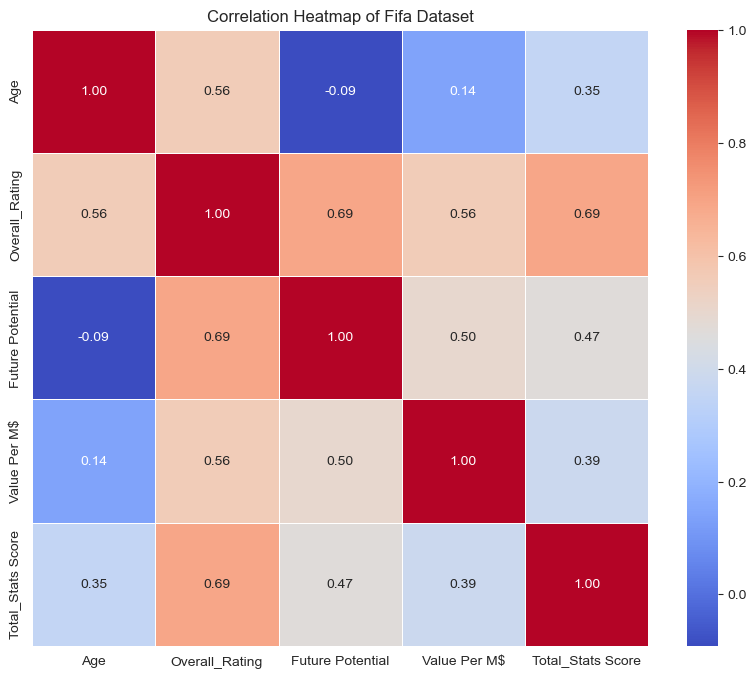

In [79]:

num_col=df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[num_col].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, 
           linewidths=0.5)

# Add title and labels
plt.title('Correlation Heatmap of Fifa Dataset')
plt.show()

In [80]:
#most related to Value Per M$
target_corr = correlation_matrix['Value Per M$'].drop('Value Per M$')  

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Most correlated features with 'Value Per M$':\n")
print(target_corr_sorted.head(10))

Most correlated features with 'Value Per M$':

Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


###  Average `Overall_Rating` per Position

In [81]:
avg_rating = (
    df.groupby('Position')['Overall_Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(avg_rating.to_string(index=False))

Position  Overall_Rating
      SW       75.000000
      RF       75.000000
      CF       66.042857
      LW       64.345979
     CDM       64.234168
      LM       64.172009
     RWB       64.063973
     LWB       64.043333
      RM       63.907731
      RW       63.718529
     CAM       63.679709
      CB       63.544448
      LB       63.276794
      ST       63.087505
      RB       62.863636
      CM       62.511767
      GK       60.987288


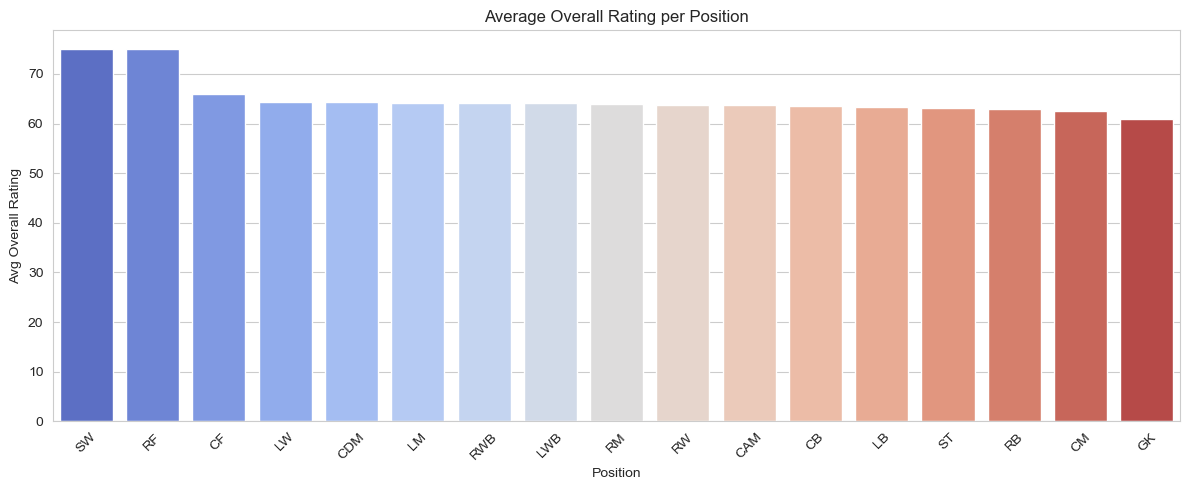

In [82]:
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_rating, x='Position', y='Overall_Rating', palette='coolwarm')
plt.title('Average Overall Rating per Position')
plt.ylabel('Avg Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

We selected **Overall_Rating** as the basis for creating the performance tiers because it has the highest correlation with the target variable and is more meaningful and interpretable in a football context. 

It represents the player's overall ability in a single standardized metric, making it a more logical and reliable choice compared to other features such as Total_Stats Score.

In [83]:
df['Tier'] = pd.qcut(df['Overall_Rating'] , q=4 , labels=['Low','Mid','High','Elite'])

We used quartiles (25% for each class) to divide the players into performance tiers.  
This approach is data-driven and ensures a balanced distribution across all classes.


In [84]:
df['Tier'].value_counts()

Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64

Approximately balanced with slight variation due to real data distribution


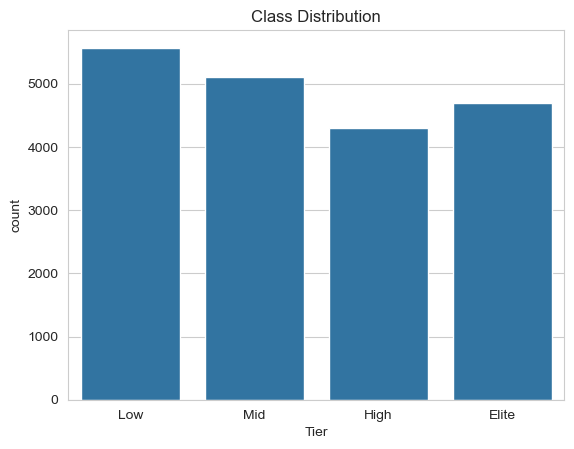

In [85]:
sns.set_style("whitegrid")
sns.countplot(x='Tier', data=df)
plt.title("Class Distribution")
plt.show()

## Data Preprocessing

In [86]:
#identifier — not a feature
df.drop(columns=[('Name')],inplace=True)

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Country            19667 non-null  str     
 1   Position           19667 non-null  str     
 2   Age                19667 non-null  int64   
 3   Overall_Rating     19667 non-null  int64   
 4   Future Potential   19667 non-null  int64   
 5   Team               19667 non-null  str     
 6   Value Per M$       19667 non-null  float64 
 7   Total_Stats Score  19667 non-null  int64   
 8   Tier               19667 non-null  category
dtypes: category(1), float64(1), int64(4), str(3)
memory usage: 1.6 MB


In [88]:
cat_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical features:",num_col)
print("Categorical features:",cat_col)

Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical features: ['Country', 'Position', 'Team', 'Tier']


In [89]:
for col in cat_col:
    print(f"{col}: {df[col].nunique()} unique values")

Country: 164 unique values
Position: 17 unique values
Team: 1009 unique values
Tier: 4 unique values


In [90]:
for col in cat_col:
    print(f"{col}: {df[col].unique()} unique values")


Country: <ArrowStringArray>
[        'Angola',          'Egypt',        'Nigeria',        'Senegal',
        'Uruguay',        'Ukraine',         'Mexico',        'England',
       'Paraguay',         'France',
 ...
       'Thailand',        'Belarus',          'Nepal',      'Singapore',
         'Bhutan',      'Indonesia',      'Gibraltar',        'Lebanon',
       'Malaysia', 'Chinese Taipei']
Length: 164, dtype: str unique values
Position: <ArrowStringArray>
[ 'LW',  'GK',  'CB',  'RB',  'CM', 'CDM', 'CAM',  'ST',  'LB',  'RM',  'CF',
  'LM',  'RW', 'RWB', 'LWB',  'RF',  'SW']
Length: 17, dtype: str unique values
Team: <ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz',
 ...
                'Le Mans',     'Zamora Fútbol Club',               'ŁKS Łódź',
   

In [91]:
print(df['Team'].unique())

<ArrowStringArray>
[    'Ittihad Alexandria',      'Tottenham Hotspur',            'Sporting CP',
                'Chelsea',                 'Mexico', 'Brighton & Hove Albion',
    'Eintracht Frankfurt',                'Antwerp',            'Vissel Kobe',
                   'Metz',
 ...
                'Le Mans',     'Zamora Fútbol Club',               'ŁKS Łódź',
                  'Cusco',    'Llaneros de Guanare',                'Trapani',
        'Desportivo Aves',        'Neuchâtel Xamax',            'Mattersburg',
    'Deportivo La Coruña']
Length: 1009, dtype: str


In [92]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 15733  |  Test size: 3934


In [93]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score,Tier
10156,Japan,LW,25,67,70,Gil Vicente,1689,High
10392,Colombia,ST,19,55,68,Midtjylland,1351,Low
8124,Portugal,RW,32,75,75,Rio Ave,2049,Elite
13075,Portugal,ST,17,61,71,Belenenses,1448,Mid
19445,Uruguay,RB,28,69,69,Wanderers,1748,Elite
...,...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680,Mid
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557,High
5390,Japan,ST,24,63,67,Shonan Bellmare,1568,Mid
860,Nigeria,CM,25,81,82,Leicester City,2042,Elite


In [94]:
X_test

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score,Tier
15659,Uruguay,CDM,34,68,68,Torque,1708,High
1350,Spain,CB,31,82,82,Athletic Club,1992,Elite
4871,Belgium,CM,22,59,65,RKC Waalwijk,1540,Mid
16532,Brazil,CDM,23,68,73,Vancouver Whitecaps,1830,High
385,Serbia,CM,27,86,86,Lazio,2250,Elite
...,...,...,...,...,...,...,...,...
7628,Ukraine,CB,32,78,78,Shakhtar Donetsk,2071,Elite
17406,Belgium,LW,20,56,70,Mechelen,1470,Low
5963,Argentina,RW,26,74,75,Charlotte,1970,Elite
14024,Denmark,RW,19,62,75,Viborg,1606,Mid


In [95]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train[['Position']])  # only train

pos_cols = ohe.get_feature_names_out(['Position'])

pos_train = pd.DataFrame(ohe.transform(X_train[['Position']]), columns=pos_cols, index=X_train.index)
pos_test  = pd.DataFrame(ohe.transform(X_test[['Position']]),  columns=pos_cols, index=X_test.index)

X_train = pd.concat([X_train, pos_train], axis=1).drop(columns=['Position'])
X_test  = pd.concat([X_test,  pos_test],  axis=1).drop(columns=['Position'])

In [96]:
def target_encode_train(X_train, y_train, col, n_splits=5, random_state=42):
    global_mean = y_train.mean()
    encoded = pd.Series(global_mean, index=X_train.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X_train):
        fold_means = y_train.iloc[train_idx].groupby(X_train[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = X_train[col].iloc[val_idx].map(fold_means).fillna(global_mean)

    
    full_means = y_train.groupby(X_train[col]).mean()
    return encoded, full_means, global_mean


for col in ['Country', 'Team']:
    enc_train, means, global_mean = target_encode_train(X_train, y_train, col)
    
    X_train[f'{col}_enc'] = enc_train
    X_test[f'{col}_enc']  = X_test[col].map(means).fillna(global_mean)  
    
    X_train = X_train.drop(columns=[col])
    X_test  = X_test.drop(columns=[col])

print("Train shape:", X_train.shape)
print("Test shape:",  X_test.shape)

Train shape: (15733, 23)
Test shape: (3934, 23)


In [97]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Tier,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,25,67,70,1689,High,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.497152,2.802500
10392,19,55,68,1351,Low,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.080662,1.798333
8124,32,75,75,2049,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.901309,1.300000
13075,17,61,71,1448,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.755643,1.718750
19445,28,69,69,1748,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.538141,1.055000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,Mid,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.232550,0.528889
11964,27,67,68,1557,High,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.328409,0.716667
5390,24,63,67,1568,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.390830,0.437500
860,25,81,82,2042,Elite,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.391250,10.655714


In [98]:
X_test

,Age,Overall_Rating,Future Potential,Total_Stats Score,Tier,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
15659,34,68,68,1708,High,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.368633,0.907500
1350,31,82,82,1992,Elite,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.276732,14.253750
4871,22,59,65,1540,Mid,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.284865,0.742500
16532,23,68,73,1830,High,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.025719,1.301053
385,27,86,86,2250,Elite,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.943929,13.470455
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,32,78,78,2071,Elite,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.699857,2.920000
17406,20,56,70,1470,Low,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.284865,0.757692
5963,26,74,75,1970,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.816283,1.313750
14024,19,62,75,1606,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.416531,0.751500


In [99]:
#scaling

cols_to_scale = ['Age', 'Future Potential', 'Total_Stats Score', 
                 'Country_enc', 'Team_enc']
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print(X_train[cols_to_scale].describe().round(2))

            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc
count  15733.00          15733.00           15733.00     15733.00  15733.00
mean      -0.00              0.00               0.00        -0.00     -0.00
std        1.00              1.00               1.00         1.00      1.00
min       -1.71             -3.80              -2.78        -1.57     -0.56
25%       -0.85             -0.72              -0.51        -0.81     -0.44
50%       -0.21             -0.10               0.05        -0.12     -0.34
75%        0.64              0.67               0.66         0.73     -0.11
max        4.48              3.60               2.79        17.56     10.73


In [100]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Tier,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.427468,67,-0.102151,0.547828,High,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.627229,0.067677
10392,-0.852089,55,-0.410505,-0.643544,Low,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.261387,-0.158581
8124,1.920283,75,0.668734,1.816744,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.134039,-0.270865
13075,-1.278607,61,0.052026,-0.301641,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.042711,-0.176513
19445,1.067246,69,-0.256328,0.755789,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025438,-0.326069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,59,-0.102151,0.516105,Mid,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.793126,-0.444612
11964,0.853986,67,-0.410505,0.082558,High,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.520911,-0.402302
5390,0.214208,63,-0.564682,0.121331,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.693890,-0.465204
860,0.427468,81,1.747973,1.792070,Elite,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.560311,1.837160


Outlier Report (Train only):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                          -3.09     2.88      129   0.8%
Future Potential             -2.80     2.75       94   0.6%
Total_Stats Score            -2.26     2.41      666   4.2%
Country_enc                  -3.13     3.04        9   0.1%
Team_enc                     -0.92     0.37     2274  14.5%


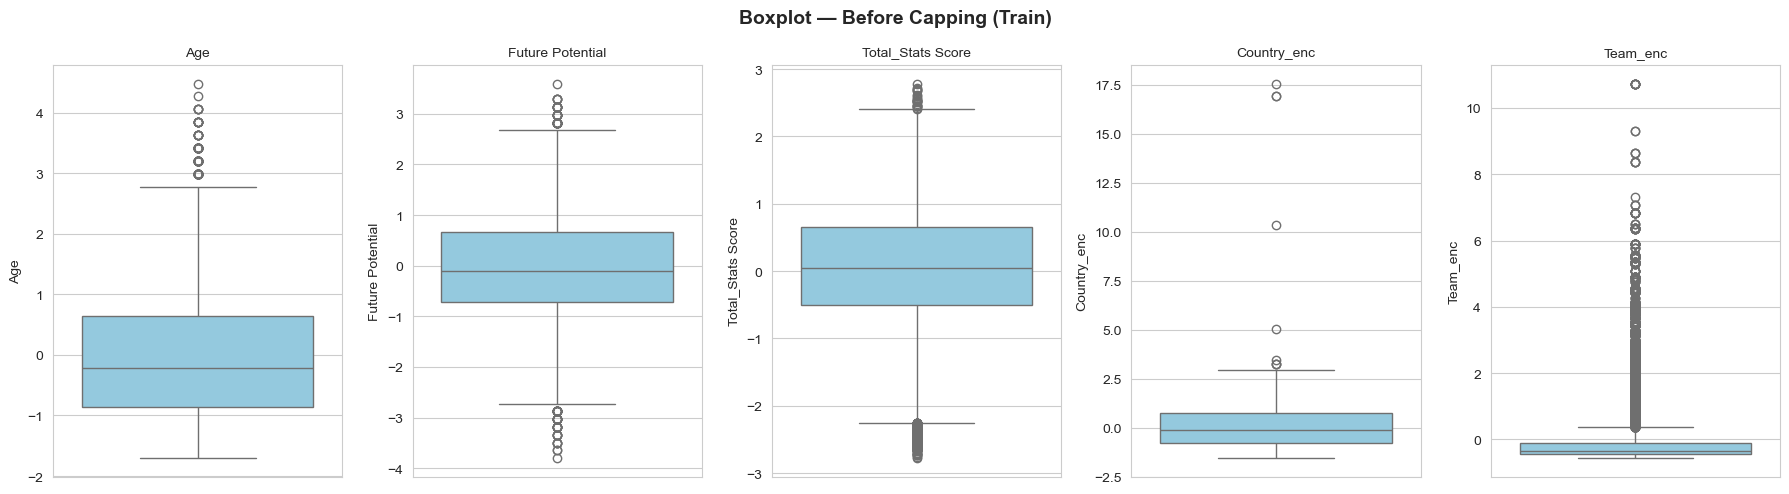

In [101]:
# الأعمدة الـ numerical بس (مش OHE)
num_cols = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc']

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers)

# ① Detection — شوفي الـ outliers الأول
print("Outlier Report (Train only):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols:
    lower, upper, count = detect_outliers_iqr(X_train, col)
    pct = count / len(X_train) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — Before Capping (Train)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



 After Capping:
            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc
count  15733.00          15733.00           15733.00     15733.00  15733.00
mean      -0.00              0.00               0.01        -0.00     -0.22
std        0.99              1.00               0.98         0.97      0.30
min       -1.71             -2.80              -2.26        -1.57     -0.56
25%       -0.85             -0.72              -0.51        -0.81     -0.44
50%       -0.21             -0.10               0.05        -0.12     -0.34
75%        0.64              0.67               0.66         0.73     -0.11
max        2.88              2.75               2.41         3.04      0.37


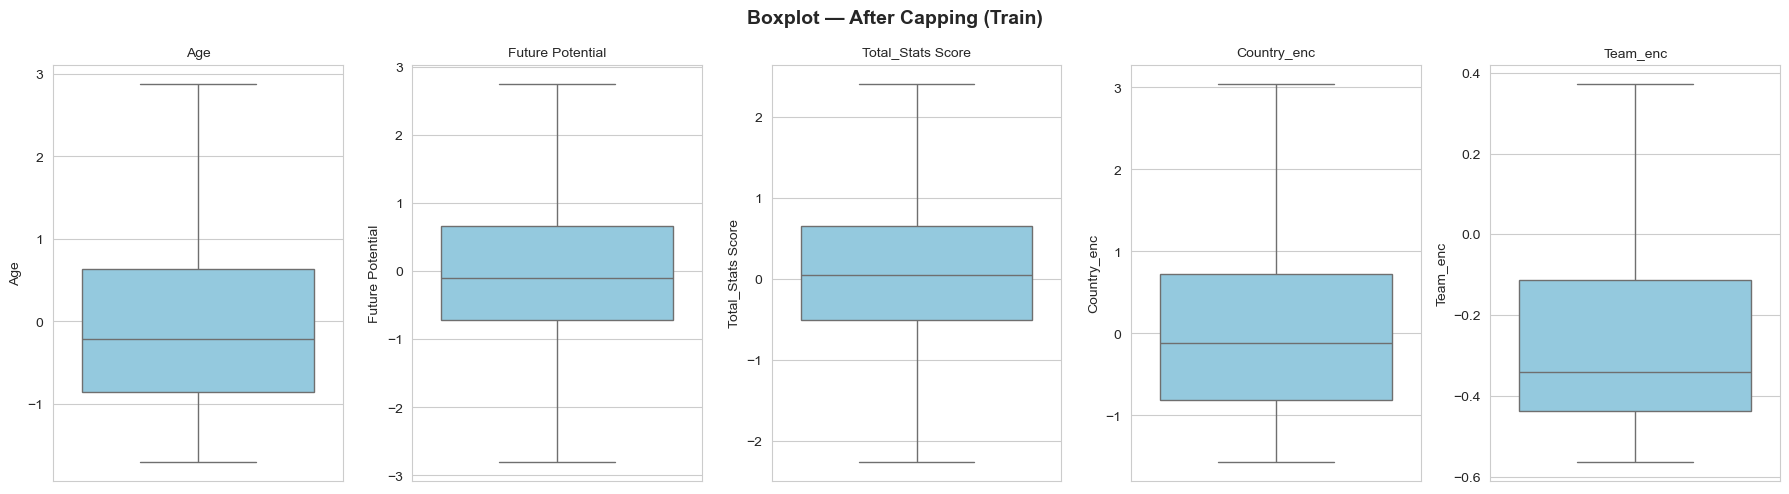

In [102]:
caps = {}
for col in num_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    caps[col] = (lower, upper)  

    
    X_train[col] = X_train[col].clip(lower, upper)


for col in num_cols:
    lower, upper = caps[col]
    X_test[col] = X_test[col].clip(lower, upper)

print("\n After Capping:")
print(X_train[num_cols].describe().round(2))

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (Train)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [103]:
X_train

,Age,Overall_Rating,Future Potential,Total_Stats Score,Tier,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.427468,67,-0.102151,0.547828,High,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.627229,0.067677
10392,-0.852089,55,-0.410505,-0.643544,Low,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.261387,-0.158581
8124,1.920283,75,0.668734,1.816744,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.134039,-0.270865
13075,-1.278607,61,0.052026,-0.301641,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.042711,-0.176513
19445,1.067246,69,-0.256328,0.755789,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025438,-0.326069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.852089,59,-0.102151,0.516105,Mid,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.793126,-0.444612
11964,0.853986,67,-0.410505,0.082558,High,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.520911,-0.402302
5390,0.214208,63,-0.564682,0.121331,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.693890,-0.465204
860,0.427468,81,1.747973,1.792070,Elite,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.560311,0.372460


In [104]:
X_test

,Age,Overall_Rating,Future Potential,Total_Stats Score,Tier,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
15659,2.346802,68,-0.410505,0.614798,High,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.080838,-0.359303
1350,1.707024,82,1.747973,1.615832,Elite,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.115480,0.372460
4871,-0.212311,59,-0.873036,0.022637,Mid,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.493610,-0.396481
16532,0.000949,68,0.360380,1.044820,High,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.212039,-0.270628
385,0.853986,86,2.364681,2.407142,Elite,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.906823,0.372460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7628,1.920283,78,1.131265,1.894289,Elite,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.126829,0.094152
17406,-0.638829,56,-0.102151,-0.224096,Low,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.493610,-0.393058
5963,0.640727,74,0.668734,1.538287,Elite,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.199824,-0.267767
14024,-0.852089,62,0.668734,0.255272,Mid,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.050807,-0.394453


In [105]:
y_test

15659     0.550
1350     21.000
4871      0.325
16532     1.800
385      72.000
          ...  
7628      9.000
17406     0.350
5963      5.000
14024     0.950
41       17.000
Name: Value Per M$, Length: 3934, dtype: float64

In [106]:
y_train

10156     1.300
10392     0.300
8124      3.900
13075     0.675
19445     1.300
          ...  
11284     0.475
11964     1.000
5390      0.700
860      27.500
15795     1.200
Name: Value Per M$, Length: 15733, dtype: float64